In [1]:
import pandas as pd
import os
from sklearn.svm import SVR
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter
import sys
from pathlib import Path

# 导入公共路径
sys.path.append(str(Path("../00_common").resolve()))
from base_path import ROOT
sys.path.append(str(Path("../02 Stacking").resolve()))
from features import features

# 输出路径：
path = ROOT / "05 基线对比" / "Mean prediction"

# 输入路径：上一步分用户的 CSV
input_folder = ROOT / "01 数据处理" / "07split_by_uid"

# 如果输出目录不存在，就创建
path.mkdir(parents=True, exist_ok=True)

print("输入文件夹：", input_folder)
print("输出路径：", path)




# 挑选出3天pam的值
output_hysteresis = path / "滞后特征"
output_abnormal = path / "异常值编码"
merged_file_path = path / "final.csv"
filtered_file_path = path / "final0.7.csv"
# 主循环中传递滞后窗口大小
lag_window = 7  # 可以灵活调整滞后窗口大小
predict_horizon = 3  # 预测几天后的 pam 变化，例如2表示 t+2

输入文件夹： /home/wei/Data/light/01 数据处理/07split_by_uid
输出路径： /home/wei/Data/light/05 基线对比/Mean prediction


# 1. 创建滞后特征 ==========

In [2]:
features = features  # 假设您有这些特征
# 从特征列表中删除 day，避免 day 进入模型特征
features = [col for col in features if col != "day"]


input_files = glob(os.path.join(input_folder, "*.csv"))
all_data = []

os.makedirs(output_hysteresis, exist_ok=True)

def extract_lagged_features(df, required_columns, lag_window, predict_horizon):
    rows = []
    for i in range(lag_window, len(df)):  # 使用动态窗口大小
        pam_t = df.loc[i, "pam"]
        if i + predict_horizon >= len(df):
            break

        pam_t_plus = df.loc[i + predict_horizon, "pam"]

        if pd.isna(pam_t) or pd.isna(pam_t_plus):
            continue

        # 提取 t-lag_window 到 t 的特征
        lagged_features = [df.loc[i - j, required_columns] for j in range(lag_window, -1, -1)]
        rolling_window = pd.DataFrame(lagged_features)

        # 计算统计特征
        rolling_mean = rolling_window.mean()
        rolling_std = rolling_window.std()
        rolling_skew = rolling_window.skew()
        # rolling_max = rolling_window.max()
        # rolling_min = rolling_window.min()

        target = pam_t_plus - pam_t
        row = (list(rolling_window.values.flatten())
            + rolling_mean.tolist()               # 均值
            + rolling_std.tolist()                # 标准差
            + rolling_skew.tolist()               # 偏度
            # + rolling_max.tolist()                # 最大值
            # + rolling_min.tolist()                # 最小值
            + [target]                            # 目标值
         )
        rows.append(row)
    return rows


for file in input_files:
    df = pd.read_csv(file)
    required_columns = [col for col in features if col in df.columns]

    rows = extract_lagged_features(df, required_columns, lag_window, predict_horizon)

    if rows:
        output_df = pd.DataFrame(
            rows,
            columns=[
                f"{col}_t-{i}" for i in range(lag_window, -1, -1) for col in required_columns
            ] + [f"{col}_mean" for col in required_columns]
              + [f"{col}_std" for col in required_columns]
              + [f"{col}_skew" for col in required_columns]
              # + [f"{col}_max" for col in required_columns]
              # + [f"{col}_min" for col in required_columns]
              + ["target"]
        )
        output_file = os.path.join(output_hysteresis, os.path.basename(file))
        output_df.to_csv(output_file, index=False)
        all_data.append(output_df)


# 2. 异常值编码 ==========

In [3]:
input_folder = output_hysteresis
os.makedirs(output_abnormal, exist_ok=True)

input_files = glob(os.path.join(input_folder, "*.csv"))

for file in input_files:
    data = pd.read_csv(file)

    if data.empty:
        print(f"跳过空文件：{file}")
        continue

    if "target" not in data.columns:
        print(f"跳过无 target 文件：{file}")
        continue

    # 这些列不参与异常检测和异常编码
    meta_cols = ["target", "day_t", "day_future"]

    # 只选择真正的数值列，排除 bool
    feature_cols = [
        col for col in data.columns
        if col not in meta_cols
        and pd.api.types.is_numeric_dtype(data[col])
        and not pd.api.types.is_bool_dtype(data[col])
    ]

    # 只对特征列填充缺失值
    feature_data = data[feature_cols].copy()
    feature_data = feature_data.fillna(-1)

    # IsolationForest 只用模型特征，不用 target/day_t/day_future
    isolation_forest = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    anomaly_scores = isolation_forest.fit_predict(feature_data)
    data["anomaly"] = anomaly_scores

    encoded_columns = {}

    # IQR 编码：只对数值特征和 anomaly 做
    encode_cols = feature_cols + ["anomaly"]

    for column in encode_cols:
        # 再保险：跳过 bool 列
        if pd.api.types.is_bool_dtype(data[column]):
            continue

        col_data = pd.to_numeric(data[column], errors="coerce").fillna(-1)

        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        encoded_columns[f"{column}_encoded"] = col_data.apply(
            lambda x: 0 if x < lower_bound else (2 if x > upper_bound else 1)
        )

    encoded_data = pd.DataFrame(encoded_columns)
    final_data = pd.concat([data, encoded_data], axis=1)

    final_file_path = os.path.join(output_abnormal, os.path.basename(file))
    final_data.to_csv(final_file_path, index=False)

    print(f"已生成异常编码文件：{final_file_path}，实例数：{len(final_data)}")

已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/1.csv，实例数：16
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/2.csv，实例数：27
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/5.csv，实例数：26
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/6.csv，实例数：46
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/8.csv，实例数：31
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/9.csv，实例数：78
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/11.csv，实例数：73
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/12.csv，实例数：63
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/13.csv，实例数：25
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/14.csv，实例数：23
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/15.csv，实例数：34
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/20.csv，实例数：24
已生成异常编码文件：/home/wei/Data/light/05 基线对比/Mean prediction/异常值编码/21.csv，实例数：22
已生成异常编码文件：/home/wei/Data/light/

# 3. 合成 Final 文件 ==========

In [4]:
directory_path = output_abnormal


final_df = pd.DataFrame()
for file_name in os.listdir(directory_path):
    if file_name.endswith(".csv"):
        file_path = os.path.join(directory_path, file_name)
        df = pd.read_csv(file_path)
        final_df = pd.concat([final_df, df], ignore_index=True)

final_df.to_csv(final_file_path, index=False)


# 4. 筛选缺失值 ==========

In [5]:
sensor_data = pd.read_csv(final_file_path)
missing_percentage = sensor_data.isnull().mean() * 100
selected_columns = missing_percentage[missing_percentage <= 30].index.tolist()
filtered_data = sensor_data[selected_columns]
filtered_data.to_csv(filtered_file_path, index=False)


# 5. 数据增强与训练 ==========

In [6]:
data = pd.read_csv(filtered_file_path)
sensor_columns = [col for col in data.columns if col not in ['target']]
data[sensor_columns] = data[sensor_columns].apply(pd.to_numeric, errors='coerce')
data[sensor_columns] = data[sensor_columns].fillna(data[sensor_columns].mean())

# 标准化
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[sensor_columns])
X = pd.DataFrame(scaled_features, columns=sensor_columns)
y = data['target']

In [7]:
# 数据增强
# 计算每个类别的样本数
class_counts = Counter(y)

# 定义采样策略：对所有类别增加 1RF.05 倍
sampling_strategy = {label: int(class_counts[label] * 1.5) for label in class_counts}

# ADASYN 对全部类别进行采样
adasyn = ADASYN(sampling_strategy='not majority', n_neighbors=3, random_state=42,)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

# 对极端值单独处理
extreme_samples = (np.abs(y) > y.mean() + 2 * y.std())
X_extreme, y_extreme = X[extreme_samples], y[extreme_samples]

# 定义极端值的采样策略
extreme_sampling_strategy = {label: int(len(y_extreme) * 2) for label in set(y_extreme)}

# 使用 SMOTE 增强极端样本
smote_extreme = SMOTE(sampling_strategy=extreme_sampling_strategy, random_state=42, k_neighbors=3)
X_extreme_resampled, y_extreme_resampled = smote_extreme.fit_resample(X_extreme, y_extreme)

# 合并增强后的数据
X_resampled = np.vstack([X_resampled, X_extreme_resampled])
y_resampled = np.hstack([y_resampled, y_extreme_resampled])


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Mean Prediction 模型
mean_model = DummyRegressor(strategy="mean")

In [9]:
mean_model.fit(X_train, y_train)

,strategy,'mean'
,constant,None
,quantile,None


# 6. 评估与可视化 ==========


In [10]:
y_pred = mean_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\n测试集上的均方误差（MSE）：{mse}")

# 极端值样本评估
threshold = 2.0
errors = np.abs(y_pred - y_test)
correct_predictions = errors <= threshold

extreme_samples = (np.abs(y_test) > 10)
extreme_mse = mean_squared_error(y_test[extreme_samples], y_pred[extreme_samples])

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")
print(f"极端值样本的MSE：{extreme_mse}")



测试集上的均方误差（MSE）：94.93943782064895

误差在 2.0 范围内的准确率：11.27%
极端值样本的MSE：171.77072272720878


In [11]:
import numpy as np
from sklearn.metrics import mean_squared_error

def bootstrap_ci_with_extreme(
    y_true,
    y_pred,
    n_bootstrap=1000,
    threshold=2.0,
    extreme_threshold=10,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)

    mse_values = []
    acc_values = []
    mse_ext_values = []

    for _ in range(n_bootstrap):
        indices = rng.choice(n, size=n, replace=True)

        y_true_sample = y_true[indices]
        y_pred_sample = y_pred[indices]

        mse = mean_squared_error(y_true_sample, y_pred_sample)
        acc = np.mean(np.abs(y_true_sample - y_pred_sample) <= threshold) * 100

        extreme_mask = np.abs(y_true_sample) > extreme_threshold
        if np.sum(extreme_mask) > 0:
            mse_ext = mean_squared_error(
                y_true_sample[extreme_mask],
                y_pred_sample[extreme_mask]
            )
            mse_ext_values.append(mse_ext)

        mse_values.append(mse)
        acc_values.append(acc)

    mse_ci = np.percentile(mse_values, [2.5, 97.5])
    acc_ci = np.percentile(acc_values, [2.5, 97.5])
    mse_ext_ci = np.percentile(mse_ext_values, [2.5, 97.5])

    return mse_ci, acc_ci, mse_ext_ci


mse_ci, acc_ci, mse_ext_ci = bootstrap_ci_with_extreme(y_test, y_pred)

print(f"MSE 95% CI: [{mse_ci[0]:.2f}, {mse_ci[1]:.2f}]")
print(f"Accuracy@2.0 95% CI: [{acc_ci[0]:.2f}%, {acc_ci[1]:.2f}%]")
print(f"MSE_ext 95% CI: [{mse_ext_ci[0]:.2f}, {mse_ext_ci[1]:.2f}]")

MSE 95% CI: [93.07, 96.71]
Accuracy@2.0 95% CI: [10.53%, 12.08%]
MSE_ext 95% CI: [170.39, 173.13]


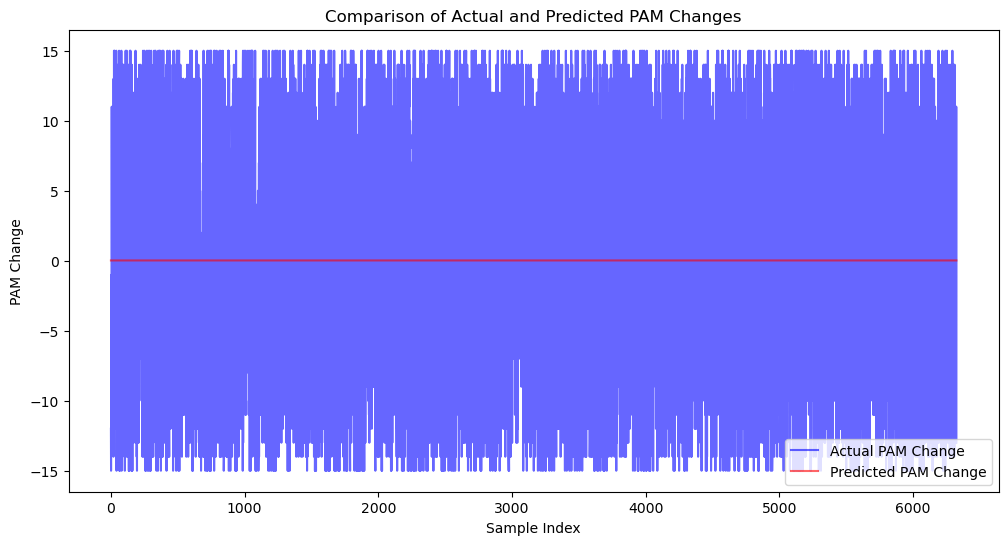

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual PAM Change", color="blue", alpha=0.6)
plt.plot(y_pred, label="Predicted PAM Change", color="red", alpha=0.6)
plt.legend()
plt.title("Comparison of Actual and Predicted PAM Changes")
plt.xlabel("Sample Index")
plt.ylabel("PAM Change")
plt.show()
